# Survey Analysis. AI Digital Resurrection Attitudes

- **Input** `FINAL-SURVEY-RESULTS-MANUAL-CLEAN.xlsx`, n = 80.
- **Output** cleaned dataset, 13 figures to `figures/`, 2 tables to `tables/`.
- **Code** The code used in this notebook was generated from a mix of reusable code from LIS modules, notably Everything Counts and AI Futures, with necessary updates researched using AI, as outlined in the Author's Statement section of the Dissertation.
- **Run** Cell menu, Run All. Missing packages install automatically.
- Method, justification and interpretation are in the dissertation. 

In [1]:
# Install anything missing
import importlib, subprocess, sys
for pkg in ["pandas","numpy","scipy","statsmodels","matplotlib","seaborn","openpyxl"]:
    try: importlib.import_module(pkg)
    except ImportError: subprocess.check_call([sys.executable,"-m","pip","install","--quiet",pkg])

import os, warnings
import numpy as np, pandas as pd
from scipy import stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titleweight"] = "bold"
pd.set_option("display.width", 150)
pd.set_option("display.max_colwidth", 90)

PATH = "FINAL-SURVEY-RESULTS-MANUAL-CLEAN.xlsx"

# Figures auto-save to figures/ as numbered PNGs at 200 dpi
os.makedirs("figures", exist_ok=True); os.makedirs("tables", exist_ok=True)
FIGURE_LOG, _N = [], {"i": 0}
def save(slug):
    _N["i"] += 1
    f = f"figures/fig_{_N['i']:02d}_{slug}.png"
    plt.gcf().savefig(f, dpi=200, bbox_inches="tight", facecolor="white")
    FIGURE_LOG.append((_N["i"], f, slug)); print(f"[saved] {f}"); plt.show()

print("Setup done.")


Setup done.


## 1. Load and clean

- Drops empty Forms scoring columns.
- Renames long question headers to short names. Skips any already renamed, so it is safe on a manually cleaned file.
- Merges UK spelling variants, groups 53 free-text ethnicities into 6 categories, splits the multi-select concerns item.
- Raw columns are kept alongside every derived one.


In [2]:
df = pd.read_excel(PATH)
df = df.drop(columns=[c for c in df.columns if str(c).startswith(("Points -","Feedback -"))], errors="ignore")
df.columns = [str(c) for c in df.columns]
print(f"Loaded {len(df)} rows, {len(df.columns)} columns")

changelog = []

RENAME = {
 "ID":"id",
 "What is your age range?":"age_range",
 "What country do you currently live in?":"country_raw",
 "How would you describe your cultural or ethnic background?":"ethnicity_raw",
 "What is your religious or spiritual tradition?":"religion",
 "How much does religion or cultural tradition shape your everyday decisions?":"religiosity",
 "How comfortable are you generally with using technology that is new or unfamiliar to you?":"tech_comfort",
 "In your cultural or family tradition, how common is it to visit graves or memorial sites?":"grave_visit_freq",
 "Which statement best reflects your own view, regardless of your background?":"continuing_bonds_view",
 "How comfortable would you personally feel using such a tool to interact with a simulation of a deceased family member?":"comfort_use_on_family",
 "How comfortable would you feel if, after you pass away, a family member used such a tool to interact with a simulation of you?":"comfort_use_on_self",
 "Which of the following concerns would matter most to you? \n\nSelect up to three.":"concerns_raw",
 "Would you be interested in trying an educational tool that explains how this technology works?":"interest_educational_tool",
 "In one or two sentences, what does your cultural or religious background teach about how the dead should be remembered, if anything?":"open_cultural_teaching",
 "Do you currently have a legal will?":"has_will",
 "Has learning about AI resurrection tools today made you more likely to write or update a will?":"more_likely_update_will",
 "Do you find this survey/research topic interesting?":"topic_interesting",
 "What, if anything, would need to change for you to feel more comfortable with this kind of technology?":"open_what_would_change",
 "What appeals to you, if anything, about this kind of technology?":"open_what_appeals",
}
df = df.rename(columns={k:v for k,v in RENAME.items() if k in df.columns})

# Headers containing line breaks or trailing spaces: match on a leading fragment
FUZZY = {
 "Do families in your tradition typically keep a home shrine":"home_shrine_freq",
 "In your tradition, how normal is it to speak to or about deceased":"speak_to_deceased_norm",
 "Before this survey, had you heard of AI tools":"heard_of_griefbots",
 "Before today, had you thought about what happens to your digital accounts":"thought_about_digital_legacy",
 "If a will writing service offered a digital legacy section":"likely_include_digital_legacy",
}
AGREE = "To what extent do you agree or disagree with the following statement:"
FUZZY.update({
 AGREE+"\n\nI would want to be clearly told":"agree_disclosure",
 AGREE+"\n\nA platform should not be allowed":"agree_consent_required",
 AGREE+"\n\nUsing AI to simulate a deceased person risks":"agree_dignity_risk",
 AGREE+"\n\nThese platforms are likely to work better":"agree_digital_divide",
 AGREE+"\n\nIt is inappropriate to charge an ongoing subscription":"agree_subscription_wrong",
})
for frag, name in FUZZY.items():
    if name in df.columns: continue
    hit = [c for c in df.columns if c.startswith(frag)]
    if hit: df = df.rename(columns={hit[0]: name})

REQUIRED = ["age_range","country_raw","ethnicity_raw","religion","religiosity","tech_comfort",
            "grave_visit_freq","home_shrine_freq","speak_to_deceased_norm","continuing_bonds_view",
            "heard_of_griefbots","comfort_use_on_family","comfort_use_on_self","agree_disclosure",
            "agree_consent_required","agree_dignity_risk","agree_digital_divide",
            "agree_subscription_wrong","concerns_raw","interest_educational_tool","has_will",
            "thought_about_digital_legacy","likely_include_digital_legacy","more_likely_update_will",
            "open_cultural_teaching","open_what_would_change","open_what_appeals"]
missing = [c for c in REQUIRED if c not in df.columns]
assert not missing, ("Columns not found after renaming: " + str(missing) +
                     "\nActual columns: " + str(list(df.columns)))

obj = df.select_dtypes("object").columns
df[obj] = df[obj].apply(lambda s: s.str.strip() if s.dtype == "object" else s)
changelog.append(("all text", "trimmed whitespace", "leading/trailing"))
print("Renamed and trimmed. All required columns present.")


Loaded 80 rows, 29 columns
Renamed and trimmed. All required columns present.


[saved] figures/fig_01_concerns_multiselect.png


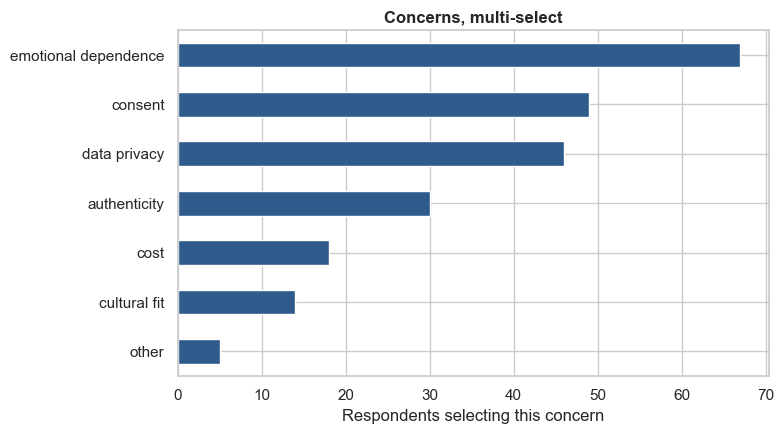

ethnicity_group
White                             41
Asian                             17
Mixed / Multiple ethnic groups     8
Middle Eastern / North African     8
Black / African                    5
Other / not specified              1
Name: count, dtype: int64


In [3]:
# Country: merge UK variants (incl. the "United Kingdon" typo)
UK = {"england","scotland","wales","northern ireland","uk","united kingdom",
      "united kingdon","great britain","britain"}
df["country_clean"] = df["country_raw"].apply(
    lambda x: "United Kingdom" if isinstance(x,str) and x.strip().lower() in UK else x)
changelog.append(("country","merged UK variants",
                  f"n={int(df['country_raw'].str.strip().str.lower().isin(UK).sum())} to 'United Kingdom'"))

# Ethnicity: 53 free-text answers to 6 groups. Single-word answers such as
# "British" coded White given the UK-dominated sample. Interpretive, not certain.
E = {**dict.fromkeys(["white british","white","white european","greek","northern irish",
     "irish & russian","european","white - british","caucasian","british white","scottish",
     "english church of england schooled but not atheist","white, culturally detached",
     "british/imperial","westernised","british","white british judeo-christian",
     "eastern european","eastern european and english"], "White"),
     **dict.fromkeys(["chinese","asian","indian","southern chinese/ hong kong","south asian",
     "afghan","indian british","british indian","hong kong","asian other","british chinese",
     "ethnically mixed malay and chinese"], "Asian"),
     **dict.fromkeys(["black african","african","somali"], "Black / African"),
     **dict.fromkeys(["turkish","kurdish","arab","persian","egyptian"], "Middle Eastern / North African"),
     **dict.fromkeys(["white and asian","white mixed","mixed race","mixed","half chinese, half english",
     "mixed race asian and north african","mixed heritage","mixed british"], "Mixed / Multiple ethnic groups"),
     "other": "Other / not specified"}
df["ethnicity_group"] = df["ethnicity_raw"].apply(
    lambda x: E.get(x.strip().lower(), "Other / not specified") if isinstance(x,str) else np.nan)
changelog.append(("ethnicity","grouped to 6 categories","raw kept in ethnicity_raw"))

# Concerns: multi-select to 7 binary columns
CONCERNS = {"Whether the deceased person consented to being simulated":"concern_consent",
 "Risk of becoming emotionally dependent on it":"concern_emotional_dependence",
 "Data privacy and who owns the data":"concern_data_privacy",
 "Accuracy or authenticity of the simulation":"concern_authenticity",
 "Cost or subscription model":"concern_cost",
 "Whether it is appropriate within my religious or cultural tradition":"concern_cultural_fit",
 "Other":"concern_other"}
for opt,col in CONCERNS.items():
    df[col] = df["concerns_raw"].apply(lambda x: int(opt in x.split(";")) if isinstance(x,str) else 0)
df["n_concerns_selected"] = df[list(CONCERNS.values())].sum(axis=1)
changelog.append(("concerns","split to 7 binary columns","plus n_concerns_selected"))

cc = df[list(CONCERNS.values())].sum().sort_values(ascending=False)
cc.index = [c.replace("concern_","").replace("_"," ") for c in cc.index]
fig, ax = plt.subplots(figsize=(8,4.5))
cc.plot(kind="barh", ax=ax, color="#2E5A8C"); ax.invert_yaxis()
ax.set_xlabel("Respondents selecting this concern"); ax.set_title("Concerns, multi-select")
plt.tight_layout(); save("concerns_multiselect")
print(df["ethnicity_group"].value_counts())


In [4]:
# Ordinal to numeric
SCALES = {
 "religiosity":["Never","Rarely","Sometimes","Often","Always"],
 "tech_comfort":["Very uncomfortable","Somewhat uncomfortable","Neutral","Somewhat comfortable","Very comfortable"],
 "grave_visit_freq":["Not practised","Uncommon","Somewhat common","Very common"],
 "home_shrine_freq":["Never","Rarely","Sometimes","Often","Always"],
 "speak_to_deceased_norm":["Not practised","Unusual","Somewhat normal","Very normal"],
 "comfort_use_on_family":["Very uncomfortable","Somewhat uncomfortable","Neither comfortable nor uncomfortable","Somewhat comfortable","Very comfortable"],
 "comfort_use_on_self":["Very uncomfortable","Somewhat uncomfortable","Neither comfortable nor uncomfortable","Somewhat comfortable","Very comfortable"],
 "agree_disclosure":["Strongly disagree","Disagree","Neutral","Agree","Strongly agree"],
 "agree_consent_required":["Strongly disagree","Disagree","Neutral","Agree","Strongly agree"],
 "agree_dignity_risk":["Strongly disagree","Disagree","Neutral","Agree","Strongly agree"],
 "agree_digital_divide":["Strongly disagree","Disagree","Neutral","Agree","Strongly agree"],
 "agree_subscription_wrong":["Strongly disagree","Disagree","Neutral","Agree","Strongly agree"],
 "interest_educational_tool":["No","Maybe","Yes"],
 "thought_about_digital_legacy":["Not at all","Very little","Somewhat","A lot","Extensively"],
 "likely_include_digital_legacy":["Extremely unlikely","Somewhat unlikely","Neutral / Neither likely nor unlikely","Somewhat likely","Extremely likely"],
 "more_likely_update_will":["No","Not sure","Yes"],
 "topic_interesting":["No","Maybe","Yes"],
}
for col, order in SCALES.items():
    df[col+"_num"] = df[col].map({lv:i+1 for i,lv in enumerate(order)})
    changelog.append((col,"ordinal code",str(order)))

df["heard_of_griefbots_bin"] = df["heard_of_griefbots"].map({"Yes":1,"No":0})
df["has_will_bin"] = df["has_will"].map({"Yes":1,"No":0})
# 'Not sure' / 'In progress' / 'Prefer not to say' left as NaN

NO_AFF = {"Atheist (do not believe in God)","Agnostic (not sure if there is a God)","Nothing in particular/Not sure"}
df["religious_affiliation_bin"] = df["religion"].apply(
    lambda x: np.nan if (not isinstance(x,str) or x=="Prefer not to say") else (0 if x in NO_AFF else 1))

# Two composite indices used throughout
df["acceptability_index"] = df[["comfort_use_on_family_num","comfort_use_on_self_num"]].mean(axis=1)
df["cultural_practice_index"] = df[["grave_visit_freq_num","home_shrine_freq_num","speak_to_deceased_norm_num"]].mean(axis=1)
AGE = ["18 - 24","25 - 34","35 - 44","45 - 54","55 - 64","65 - 74"]
df["age_num"] = df["age_range"].map({a:i+1 for i,a in enumerate(AGE)})
changelog += [("index","acceptability_index","mean of the two comfort items, 1-5"),
              ("index","cultural_practice_index","mean of grave visit, home shrine, speak-to-deceased"),
              ("age_range","ordinal code age_num",str(AGE))]

with pd.ExcelWriter("Survey_Cleaned.xlsx") as xl:
    df.to_excel(xl, sheet_name="cleaned_data", index=False)
    pd.DataFrame(changelog, columns=["Field","Action","Detail"]).to_excel(xl, sheet_name="changelog", index=False)
print("Cleaned data and changelog written to Survey_Cleaned.xlsx")
print(df[["acceptability_index","cultural_practice_index","age_num"]].describe().round(3))


Cleaned data and changelog written to Survey_Cleaned.xlsx
       acceptability_index  cultural_practice_index  age_num
count               80.000                   79.000   80.000
mean                 1.706                    2.409    1.662
std                  0.786                    0.937    1.158
min                  1.000                    1.000    1.000
25%                  1.000                    1.667    1.000
50%                  1.500                    2.500    1.000
75%                  2.000                    3.000    2.000
max                  4.000                    4.500    6.000


## 2. Sample profile

- Convenience sample, 72 hour window, UK-dominated and young.
- Not representative. Treated as exploratory throughout.


[saved] figures/fig_02_sample_age_country.png


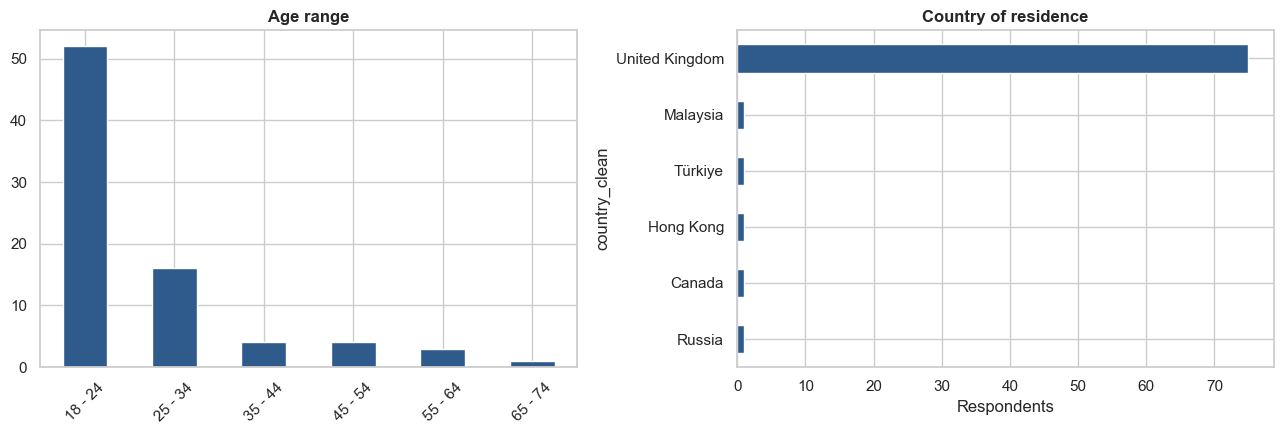

68 of 80 (85%) aged 18-34
75 of 80 in the United Kingdom


In [5]:
fig, ax = plt.subplots(1,2, figsize=(13,4.5))
df["age_range"].value_counts().reindex(AGE).dropna().plot(kind="bar", ax=ax[0], color="#2E5A8C")
ax[0].set_title("Age range"); ax[0].set_xlabel(""); ax[0].tick_params(axis="x", rotation=45)
df["country_clean"].value_counts().head(8).plot(kind="barh", ax=ax[1], color="#2E5A8C")
ax[1].invert_yaxis(); ax[1].set_title("Country of residence"); ax[1].set_xlabel("Respondents")
plt.tight_layout(); save("sample_age_country")

n1834 = int((df["age_range"].isin(["18 - 24","25 - 34"])).sum())
print(f"{n1834} of {len(df)} ({round(100*n1834/len(df))}%) aged 18-34")
print(f"{int((df['country_clean']=='United Kingdom').sum())} of {len(df)} in the United Kingdom")


[saved] figures/fig_03_sample_ethnicity_religion.png


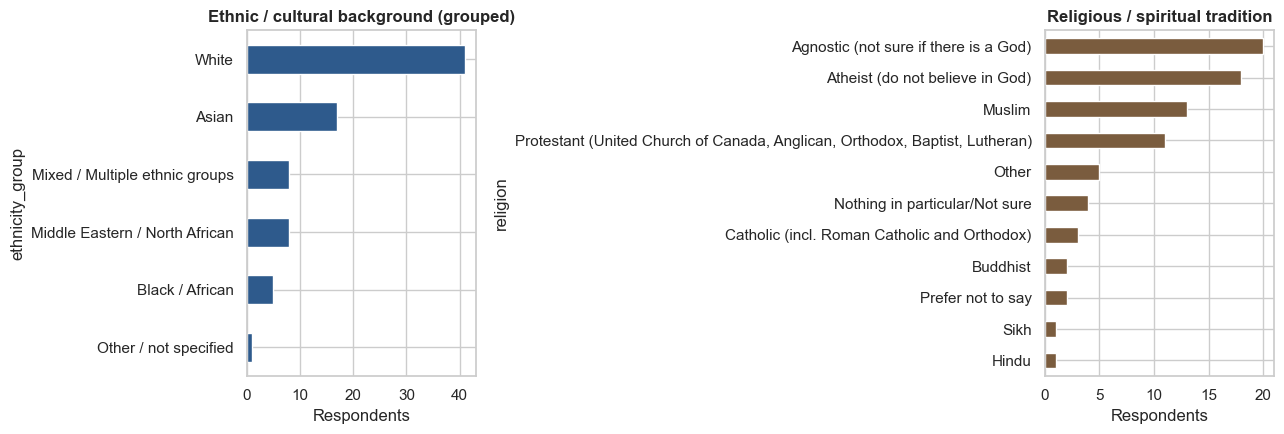

In [6]:
fig, ax = plt.subplots(1,2, figsize=(13,4.5))
df["ethnicity_group"].value_counts().plot(kind="barh", ax=ax[0], color="#2E5A8C")
ax[0].invert_yaxis(); ax[0].set_title("Ethnic / cultural background (grouped)"); ax[0].set_xlabel("Respondents")
df["religion"].value_counts().plot(kind="barh", ax=ax[1], color="#7A5C3E")
ax[1].invert_yaxis(); ax[1].set_title("Religious / spiritual tradition"); ax[1].set_xlabel("Respondents")
plt.tight_layout(); save("sample_ethnicity_religion")


## 3. Core attitudes

- Acceptability index = mean of the two comfort items, 1 to 5.
- Strong floor effect: median 1.5, 45 per cent give the minimum on both items.
- Agreement with procedural safeguards is near-consensus regardless of personal comfort. This contrast is the central finding.


[saved] figures/fig_04_core_comfort_items.png


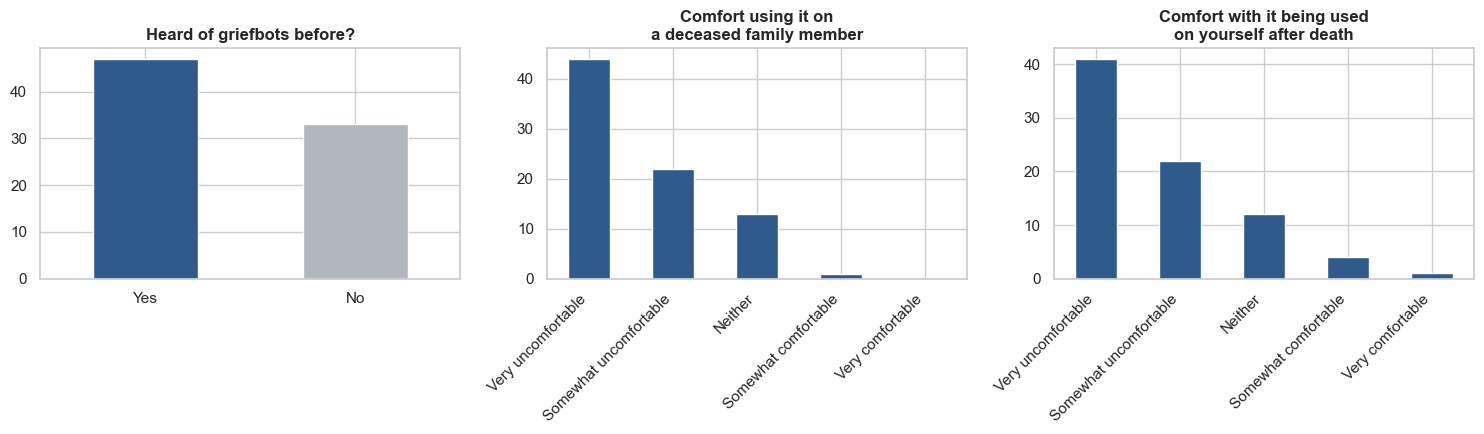

Acceptability index: median 1.5, mean 1.71
Minimum on BOTH comfort items: 36 of 80 (45%)


In [7]:
fig, ax = plt.subplots(1,3, figsize=(15,4.5))
df["heard_of_griefbots"].value_counts().plot(kind="bar", ax=ax[0], color=["#2E5A8C","#B0B7BF"])
ax[0].set_title("Heard of griefbots before?"); ax[0].set_xlabel(""); ax[0].tick_params(axis="x", rotation=0)
c_order = SCALES["comfort_use_on_family"]
for a, col, t in [(ax[1],"comfort_use_on_family","Comfort using it on\na deceased family member"),
                  (ax[2],"comfort_use_on_self","Comfort with it being used\non yourself after death")]:
    df[col].value_counts().reindex(c_order).fillna(0).plot(kind="bar", ax=a, color="#2E5A8C")
    a.set_title(t); a.set_xlabel(""); a.tick_params(axis="x", rotation=45)
    a.set_xticklabels([l.get_text().replace("Neither comfortable nor uncomfortable","Neither") for l in a.get_xticklabels()],
                      ha="right")
plt.tight_layout(); save("core_comfort_items")

both_min = int(((df["comfort_use_on_family_num"]==1)&(df["comfort_use_on_self_num"]==1)).sum())
print(f"Acceptability index: median {df['acceptability_index'].median()}, mean {df['acceptability_index'].mean():.2f}")
print(f"Minimum on BOTH comfort items: {both_min} of {len(df)} ({round(100*both_min/len(df))}%)")


[saved] figures/fig_05_procedural_safeguards_agreement.png


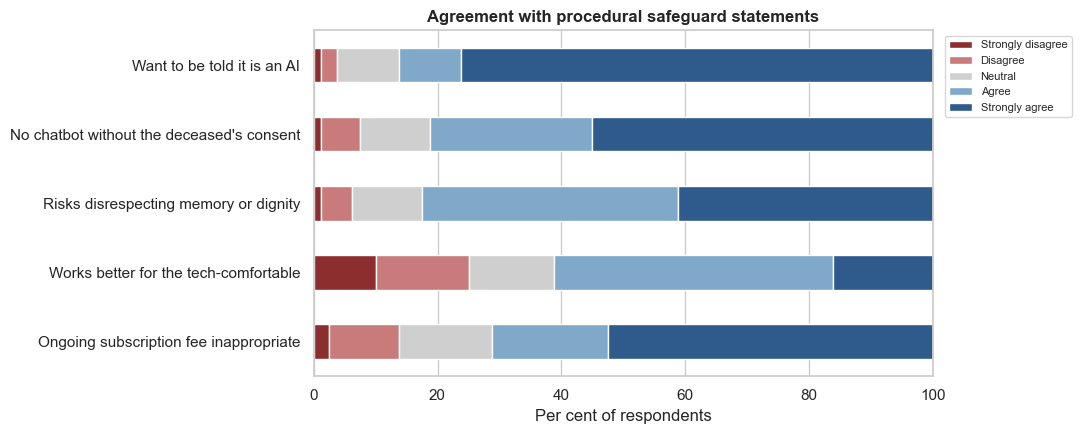

 86.2% agree/strongly agree: Want to be told it is an AI
 81.2% agree/strongly agree: No chatbot without the deceased's consent
 82.5% agree/strongly agree: Risks disrespecting memory or dignity
 61.2% agree/strongly agree: Works better for the tech-comfortable
 71.2% agree/strongly agree: Ongoing subscription fee inappropriate


In [8]:
AG = ["Strongly disagree","Disagree","Neutral","Agree","Strongly agree"]
LABELS = {"agree_disclosure":"Want to be told it is an AI",
          "agree_consent_required":"No chatbot without the deceased's consent",
          "agree_dignity_risk":"Risks disrespecting memory or dignity",
          "agree_digital_divide":"Works better for the tech-comfortable",
          "agree_subscription_wrong":"Ongoing subscription fee inappropriate"}
prop = pd.DataFrame({LABELS[c]: df[c].value_counts(normalize=True).reindex(AG).fillna(0)*100
                     for c in LABELS}).T[AG]
fig, ax = plt.subplots(figsize=(11,4.5))
prop.plot(kind="barh", stacked=True, ax=ax,
          color=["#8C2E2E","#C97A7A","#CFCFCF","#7FA8C9","#2E5A8C"])
ax.invert_yaxis(); ax.set_xlabel("Per cent of respondents"); ax.set_xlim(0,100)
ax.set_title("Agreement with procedural safeguard statements")
ax.legend(bbox_to_anchor=(1.01,1), loc="upper left", fontsize=8)
plt.tight_layout(); save("procedural_safeguards_agreement")

for c,l in LABELS.items():
    s = df[c].dropna()
    print(f"{100*s.isin(['Agree','Strongly agree']).sum()/len(s):5.1f}% agree/strongly agree: {l}")


## 4. Wills and digital legacy

- Only 12.5 per cent hold a will, unsurprising given the age profile.
- 61 per cent would add a digital legacy section if offered, 31 per cent say the survey itself made them more likely to act.
- That gap is the empirical case for the education artefact.


[saved] figures/fig_06_wills_and_digital_legacy.png


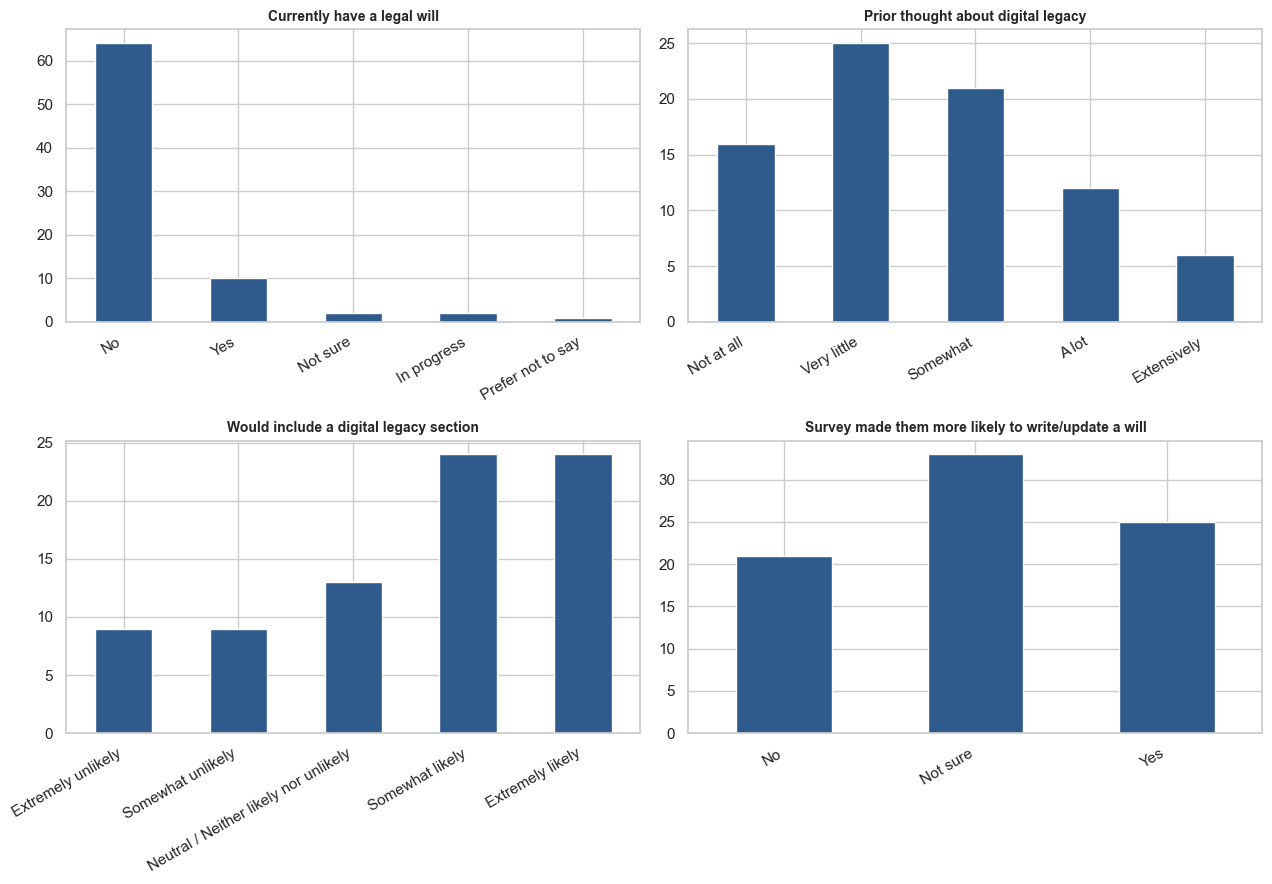

Have a will: 10/80 = 12.5%
Would include digital legacy: 48/79 = 61%
More likely to write/update a will: 25/80 = 31%


In [9]:
fig, ax = plt.subplots(2,2, figsize=(13,9))
for a,(col,t) in zip(ax.flat, [("has_will","Currently have a legal will"),
                               ("thought_about_digital_legacy","Prior thought about digital legacy"),
                               ("likely_include_digital_legacy","Would include a digital legacy section"),
                               ("more_likely_update_will","Survey made them more likely to write/update a will")]):
    order = SCALES.get(col)
    vc = df[col].value_counts()
    if order: vc = vc.reindex([o for o in order if o in vc.index]).dropna()
    vc.plot(kind="bar", ax=a, color="#2E5A8C")
    a.set_title(t, fontsize=10); a.set_xlabel(""); a.tick_params(axis="x", rotation=30)
    for lab in a.get_xticklabels(): lab.set_ha("right")
plt.tight_layout(); save("wills_and_digital_legacy")

n_w = int((df["has_will"]=="Yes").sum())
dl = df["likely_include_digital_legacy"].dropna()
n_dl = int(dl.isin(["Somewhat likely","Extremely likely"]).sum())
n_m = int((df["more_likely_update_will"]=="Yes").sum())
print(f"Have a will: {n_w}/{len(df)} = {100*n_w/len(df):.1f}%")
print(f"Would include digital legacy: {n_dl}/{len(dl)} = {round(100*n_dl/len(dl))}%")
print(f"More likely to write/update a will: {n_m}/{len(df)} = {round(100*n_m/len(df))}%")


## 5. Open-text thematic analysis

Braun and Clarke (2006), six phases, coded manually across the three open-text items. Six final themes:

- **A. Consent as precondition.** Prior consent treated as the minimum condition, not a preference.
- **B. Grief as commercially exploitable.** Any subscription or profit motive read as predatory.
- **C. Existing ritual as the sanctioned channel.** Prayer, graves, storytelling healthy; a dataset relationship is not.
- **D. Authenticity doubt.** No simulation could be genuine, regardless of technical progress.
- **E. Fascination alongside discomfort.** Impressive and unwanted at the same time, not resolved.
- **F. Memory retrieval preferred to personality simulation.** Surfacing real messages troubles people far less than a simulated personality.

The chart below counts *candidate codes* by keyword as a mechanical cross-check on the manual reading. Nine bars, not six themes. Keyword counting cannot separate endorsement from rejection.


[saved] figures/fig_07_thematic_keyword_crosscheck.png


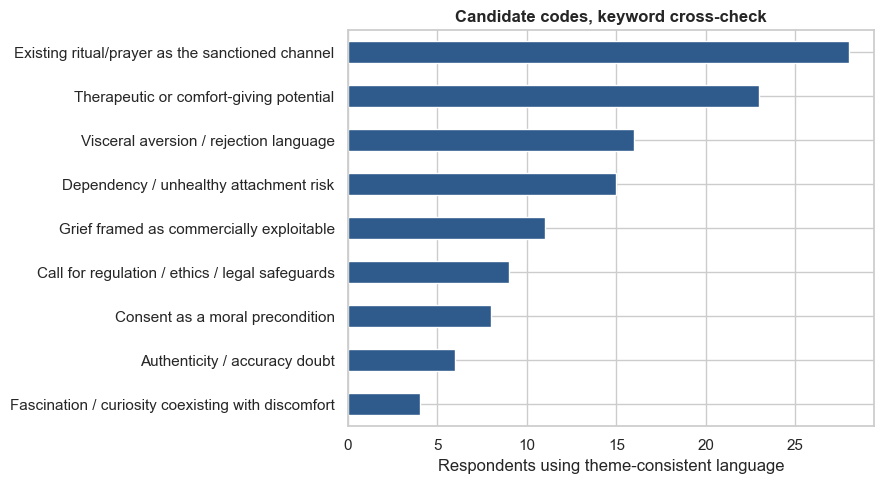

Existing ritual/prayer as the sanctioned channel      28
Therapeutic or comfort-giving potential               23
Visceral aversion / rejection language                16
Dependency / unhealthy attachment risk                15
Grief framed as commercially exploitable              11
Call for regulation / ethics / legal safeguards        9
Consent as a moral precondition                        8
Authenticity / accuracy doubt                          6
Fascination / curiosity coexisting with discomfort     4
dtype: int64


In [10]:
KW = {"Consent as a moral precondition":["consent"],
 "Grief framed as commercially exploitable":["subscri","pay","charge","profit","commerc","exploit","money"," cost","afford"],
 "Existing ritual/prayer as the sanctioned channel":["pray","grave","shrine","altar","ritual","offering","festival"],
 "Visceral aversion / rejection language":["creep","spooky","weird","wrong","disgust","sick","horrif","blasphem","repellent","never"],
 "Authenticity / accuracy doubt":["accura","authentic","replicat","not real","not the same","not actually"],
 "Dependency / unhealthy attachment risk":["depend","addict","obsess","move on","unhealthy","psychosis"],
 "Call for regulation / ethics / legal safeguards":["regulat","legal","law","ethic","framework","safeguard","gdpr"],
 "Fascination / curiosity coexisting with discomfort":["fascinat","interesting","impress","curious"],
 "Therapeutic or comfort-giving potential":["comfort","therap","heal","closure","grieving process","help"]}
txt = df[["open_cultural_teaching","open_what_would_change","open_what_appeals"]].fillna("").agg(" ".join, axis=1).str.lower()
counts = pd.Series({t: int(txt.apply(lambda x: any(k in x for k in ks)).sum()) for t,ks in KW.items()}).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9,5))
counts.plot(kind="barh", ax=ax, color="#2E5A8C"); ax.invert_yaxis()
ax.set_xlabel("Respondents using theme-consistent language"); ax.set_title("Candidate codes, keyword cross-check")
plt.tight_layout(); save("thematic_keyword_crosscheck")
print(counts)


## 6. Hypothesis test

- **Hypothesis** religiosity predicts lower acceptability; technology comfort and openness to continuing bonds predict higher.
- **Result** not supported. No predictor significant. Regression explains ~2 per cent of variance.
- Read as restriction of range, not as evidence the relationship does not exist in a wider population.


H1 religiosity -> acceptability (pred. negative)     n= 80  rho=-0.108  p=0.339  ns
H2 tech comfort -> acceptability (pred. positive)    n= 80  rho=-0.021  p=0.851  ns
H3 continuing-bonds openness (pred. positive)        n= 72  rho=+0.136  p=0.253  ns
[saved] figures/fig_08_hypothesis_scatterplots.png


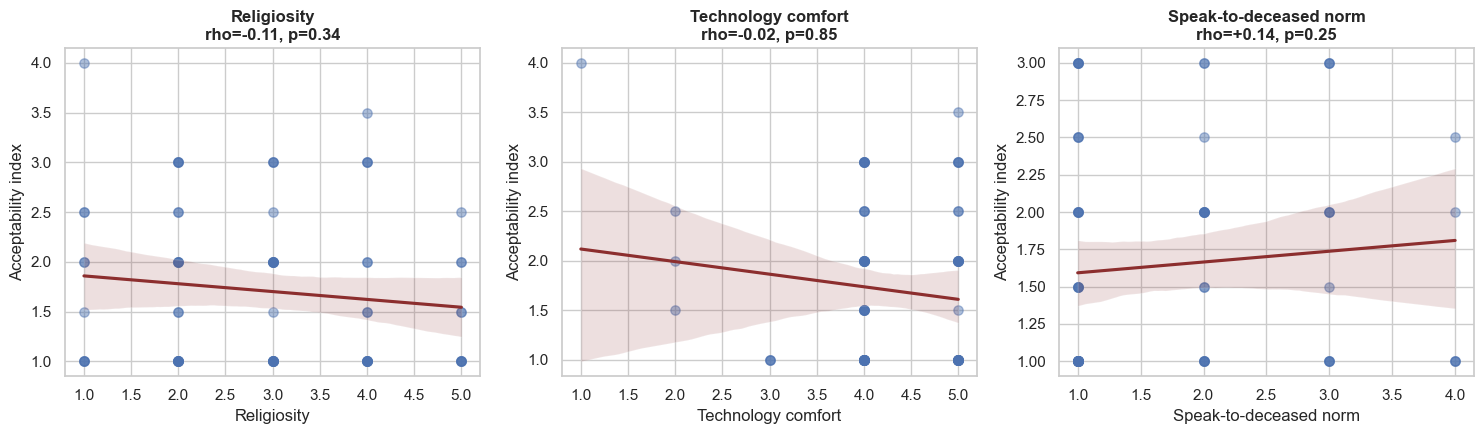

In [11]:
def rho(a, b, label):
    d = df[[a,b]].dropna()
    r, p = stats.spearmanr(d[a], d[b])
    print(f"{label:52s} n={len(d):3d}  rho={r:+.3f}  p={p:.3f}  {'SIG' if p<0.05 else 'ns'}")
    return r, p, len(d)

r1,p1,n1 = rho("religiosity_num","acceptability_index","H1 religiosity -> acceptability (pred. negative)")
r2,p2,n2 = rho("tech_comfort_num","acceptability_index","H2 tech comfort -> acceptability (pred. positive)")
r3,p3,n3 = rho("speak_to_deceased_norm_num","acceptability_index","H3 continuing-bonds openness (pred. positive)")

fig, ax = plt.subplots(1,3, figsize=(15,4.5))
for a,(x,t,rr,pp) in zip(ax, [("religiosity_num","Religiosity",r1,p1),
                              ("tech_comfort_num","Technology comfort",r2,p2),
                              ("speak_to_deceased_norm_num","Speak-to-deceased norm",r3,p3)]):
    d = df[[x,"acceptability_index"]].dropna()
    sns.regplot(data=d, x=x, y="acceptability_index", ax=a, scatter_kws={"alpha":.45,"s":45}, line_kws={"color":"#8C2E2E"})
    a.set_title(f"{t}\nrho={rr:+.2f}, p={pp:.2f}"); a.set_xlabel(t); a.set_ylabel("Acceptability index")
plt.tight_layout(); save("hypothesis_scatterplots")


In [12]:
# Multiple regression, reported for comparability with prior work, not as primary evidence
cols = ["acceptability_index","religiosity_num","tech_comfort_num","speak_to_deceased_norm_num"]
rd = df[cols].dropna()
model = sm.OLS(rd["acceptability_index"], sm.add_constant(rd[cols[1:]])).fit()
print(model.summary().tables[0])
print(model.summary().tables[1])

# Affiliation vs none
mw = df[["religious_affiliation_bin","acceptability_index"]].dropna()
gy = mw.loc[mw["religious_affiliation_bin"]==1,"acceptability_index"]
gn = mw.loc[mw["religious_affiliation_bin"]==0,"acceptability_index"]
U, pmw = stats.mannwhitneyu(gy, gn, alternative="two-sided")
r_rb = 1 - (2*U)/(len(gy)*len(gn))
print(f"\nAffiliation n={len(gy)} mean={gy.mean():.2f} | None n={len(gn)} mean={gn.mean():.2f}")
print(f"Mann-Whitney U={U:.1f}, p={pmw:.3f}, rank-biserial r={r_rb:+.3f}")


                             OLS Regression Results                            
Dep. Variable:     acceptability_index   R-squared:                       0.021
Model:                             OLS   Adj. R-squared:                 -0.023
Method:                  Least Squares   F-statistic:                    0.4746
Date:                 Tue, 04 Aug 2026   Prob (F-statistic):              0.701
Time:                         03:18:42   Log-Likelihood:                -78.617
No. Observations:                   72   AIC:                             165.2
Df Residuals:                       68   BIC:                             174.3
Df Model:                            3                                         
Covariance Type:             nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const     

## 7. Culture

- Existing continuing-bonds practice differs significantly by ethnicity group.
- Acceptability of AI simulation does not.
- Culture shapes how people already relate to the dead, but not their view of this technology. Uneven group sizes, so read as indicative.


Cultural practice by ethnicity: H=14.23, p=0.014
Acceptability by ethnicity:     H=4.40, p=0.493

                                 n  practice  acceptability
ethnicity_group                                            
Asian                           17      3.03           1.85
Middle Eastern / North African   8      2.79           1.75
White                           41      2.25           1.67
Black / African                  5      2.20           1.30
Mixed / Multiple ethnic groups   8      1.83           1.88
Other / not specified            1      1.67           1.00
[saved] figures/fig_09_cultural_practice_by_ethnicity.png


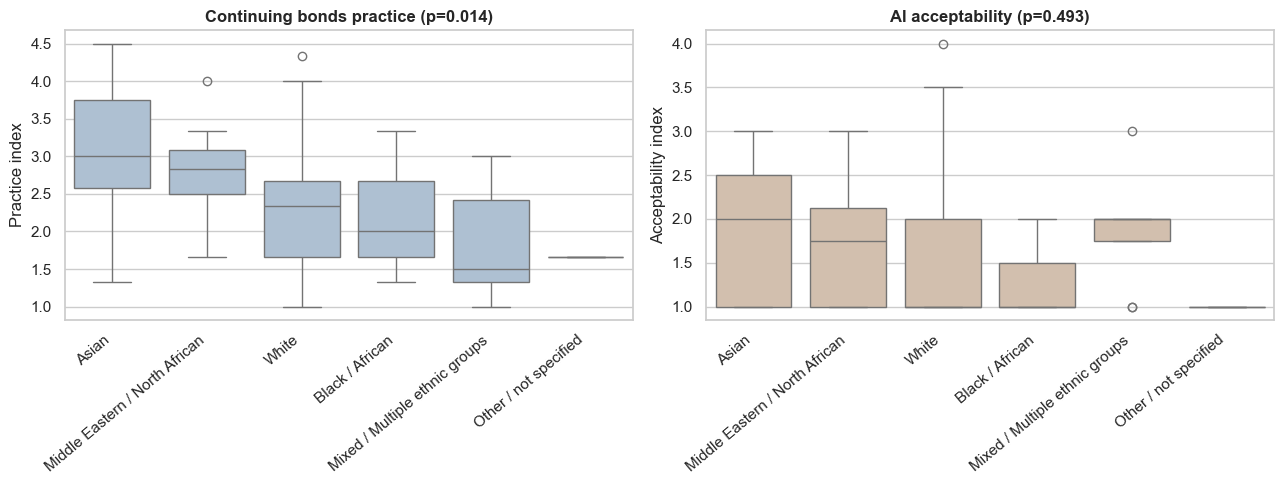

In [13]:
cp = [g["cultural_practice_index"].dropna().values for _,g in df.groupby("ethnicity_group")]
ac = [g["acceptability_index"].dropna().values for _,g in df.groupby("ethnicity_group")]
H_cp,p_cp = stats.kruskal(*[g for g in cp if len(g)])
H_ac,p_ac = stats.kruskal(*[g for g in ac if len(g)])
print(f"Cultural practice by ethnicity: H={H_cp:.2f}, p={p_cp:.3f}")
print(f"Acceptability by ethnicity:     H={H_ac:.2f}, p={p_ac:.3f}\n")

means = (df.groupby("ethnicity_group")
           .agg(n=("acceptability_index","size"),
                practice=("cultural_practice_index","mean"),
                acceptability=("acceptability_index","mean"))
           .sort_values("practice", ascending=False).round(2))
print(means)

order = means.index.tolist()
fig, ax = plt.subplots(1,2, figsize=(13,5))
sns.boxplot(data=df, x="ethnicity_group", y="cultural_practice_index", order=order, ax=ax[0], color="#A8C0D8")
ax[0].set_title(f"Continuing bonds practice (p={p_cp:.3f})"); ax[0].set_xlabel(""); ax[0].set_ylabel("Practice index")
sns.boxplot(data=df, x="ethnicity_group", y="acceptability_index", order=order, ax=ax[1], color="#D8BFA8")
ax[1].set_title(f"AI acceptability (p={p_ac:.3f})"); ax[1].set_xlabel(""); ax[1].set_ylabel("Acceptability index")
for a in ax: a.tick_params(axis="x", rotation=40); [l.set_ha("right") for l in a.get_xticklabels()]
plt.tight_layout(); save("cultural_practice_by_ethnicity")


## 8. Age, and other cross-checks

- No age effect on acceptability. Age band is almost entirely 18 to 34, so this is uninformative rather than a real null.
- Will ownership rises with age at p = 0.065, the only near-trend in the data.


Age vs acceptability                                 n= 80  rho=+0.051  p=0.656  ns
Age vs would include digital legacy                  n= 79  rho=+0.108  p=0.343  ns
Age vs already has a will                            n= 74  rho=+0.216  p=0.065  ns
Age vs technology comfort                            n= 80  rho=+0.007  p=0.948  ns
Tech comfort vs digital legacy intent                n= 79  rho=+0.199  p=0.079  ns
Cultural practice vs acceptability                   n= 79  rho=+0.054  p=0.637  ns
[saved] figures/fig_10_acceptability_by_will_intent.png


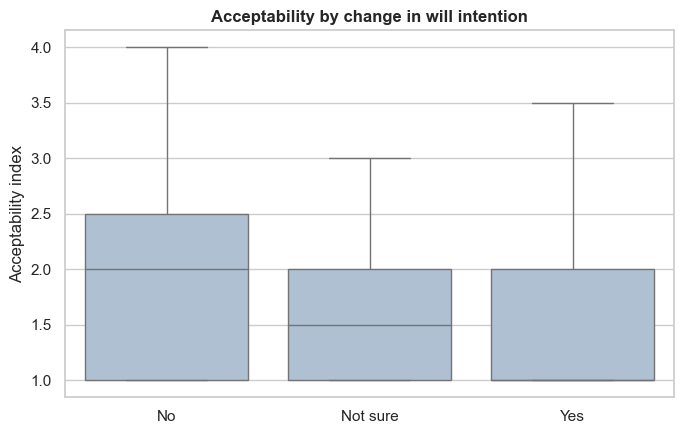

In [14]:
for a,b,l in [("age_num","acceptability_index","Age vs acceptability"),
              ("age_num","likely_include_digital_legacy_num","Age vs would include digital legacy"),
              ("age_num","has_will_bin","Age vs already has a will"),
              ("age_num","tech_comfort_num","Age vs technology comfort"),
              ("tech_comfort_num","likely_include_digital_legacy_num","Tech comfort vs digital legacy intent"),
              ("cultural_practice_index","acceptability_index","Cultural practice vs acceptability")]:
    rho(a,b,l)

fig, ax = plt.subplots(figsize=(7,4.5))
sns.boxplot(data=df[df["more_likely_update_will"].isin(["No","Not sure","Yes"])],
            x="more_likely_update_will", y="acceptability_index",
            order=["No","Not sure","Yes"], ax=ax, color="#A8C0D8")
ax.set_title("Acceptability by change in will intention"); ax.set_xlabel(""); ax.set_ylabel("Acceptability index")
plt.tight_layout(); save("acceptability_by_will_intent")


## 9. Cross-tab explorer

- `explore(var1, var2)` cross-tabulates any two categorical columns and runs a chi-square where cell counts allow.
- Two demonstrations below. Both are sparse, so neither is reported in the dissertation.


Cross-tab religion x continuing_bonds_view  (n=80)
continuing_bonds_view                                                        I have not thought about this before  \
religion                                                                                                            
Agnostic (not sure if there is a God)                                                                           1   
Atheist (do not believe in God)                                                                                 1   
Buddhist                                                                                                        0   
Catholic (incl. Roman Catholic and Orthodox)                                                                    1   
Hindu                                                                                                           0   
Muslim                                                                                                          2   
Nothing in pa

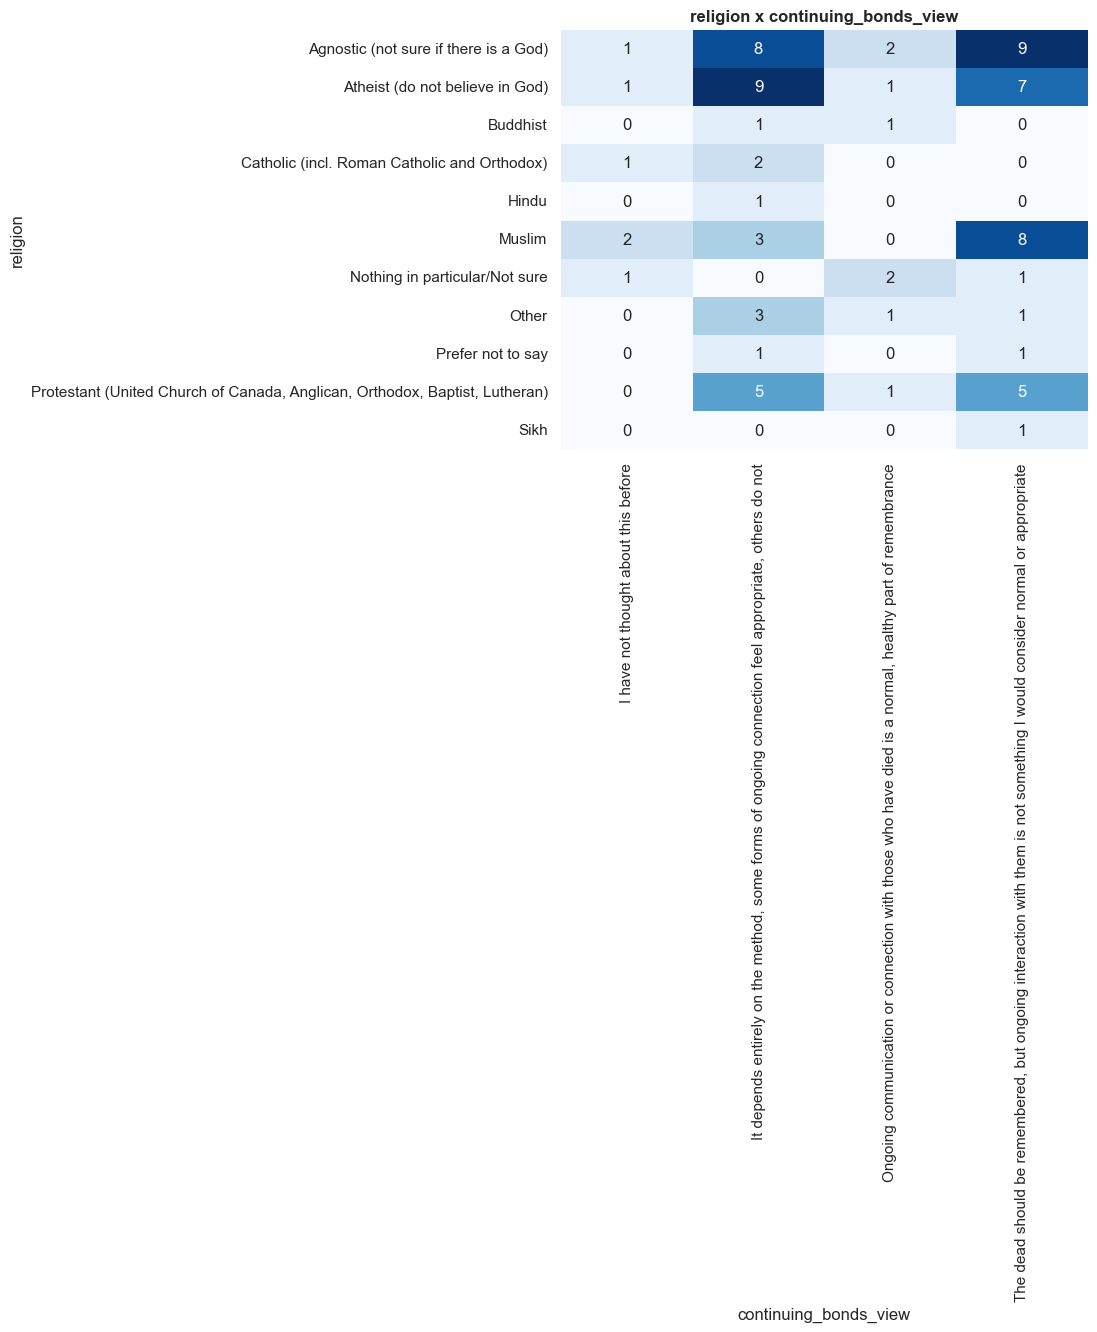

In [15]:
def explore(v1, v2, min_expected=5):
    ct = pd.crosstab(df[v1], df[v2])
    print(f"Cross-tab {v1} x {v2}  (n={ct.values.sum()})"); print(ct)
    chi2, p, dof, exp = stats.chi2_contingency(ct)
    small = (exp < min_expected).sum()
    print(f"\nchi2={chi2:.2f}, dof={dof}, p={p:.3f}")
    if small: print(f"WARNING: {small}/{exp.size} expected counts < {min_expected}. Not reliable.")
    fig, ax = plt.subplots(figsize=(min(12, 2+1.2*ct.shape[1]), 0.5+0.45*ct.shape[0]))
    sns.heatmap(ct, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(f"{v1} x {v2}")
    plt.tight_layout()
    return ct

_ = explore("religion","continuing_bonds_view"); save("religion_by_continuing_bonds")


Cross-tab heard_of_griefbots x interest_educational_tool  (n=80)
interest_educational_tool  Maybe  No  Yes
heard_of_griefbots                       
No                            10  15    8
Yes                           19  19    9

chi2=0.90, dof=2, p=0.638
[saved] figures/fig_12_awareness_by_tool_interest.png


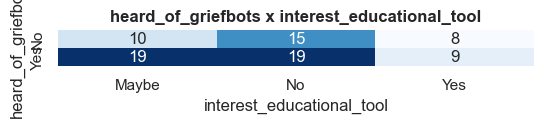

In [16]:
_ = explore("heard_of_griefbots","interest_educational_tool"); save("awareness_by_tool_interest")


## 10. Outputs

- 13 figures in `figures/`, 2 tables in `tables/`.
- Placement in the dissertation is set out in `Figure_Placement_Guide.docx`.


In [17]:
tbl_hyp = pd.DataFrame([
 ["Religiosity","Negative",f"{r1:+.2f}",f"{p1:.2f}",n1,"Not supported"],
 ["General technology comfort","Positive",f"{r2:+.2f}",f"{p2:.2f}",n2,"Not supported"],
 ["Openness to speaking with the deceased","Positive",f"{r3:+.2f}",f"{p3:.2f}",n3,"Not supported"],
], columns=["Predictor","Hypothesised direction","Spearman rho","p","n","Outcome"])
tbl_hyp.to_csv("tables/table_4_2_hypothesis_tests.csv", index=False)

tbl_eth = means.reset_index().rename(columns={
 "ethnicity_group":"Ethnicity group","n":"n (all respondents)",
 "practice":"Continuing bonds practice index (mean)","acceptability":"AI acceptability index (mean)"})
tbl_eth.to_csv("tables/table_4_3_ethnicity_group_means.csv", index=False)

print("Table 4.2\n", tbl_hyp.to_string(index=False))
print("\nTable 4.3\n", tbl_eth.to_string(index=False))
print("\nFigures:")
print(pd.DataFrame(FIGURE_LOG, columns=["ID","File","Slug"]).to_string(index=False))


Table 4.2
                              Predictor Hypothesised direction Spearman rho    p  n       Outcome
                           Religiosity               Negative        -0.11 0.34 80 Not supported
            General technology comfort               Positive        -0.02 0.85 80 Not supported
Openness to speaking with the deceased               Positive        +0.14 0.25 72 Not supported

Table 4.3
                Ethnicity group  n (all respondents)  Continuing bonds practice index (mean)  AI acceptability index (mean)
                         Asian                   17                                    3.03                           1.85
Middle Eastern / North African                    8                                    2.79                           1.75
                         White                   41                                    2.25                           1.67
               Black / African                    5                                    2.20      

## 11. Consistency check against the dissertation

- Re-derives every survey number quoted in the dissertation and prints PASS or MISMATCH.
- Run after any edit to the text or the data. A mismatch means the two have drifted apart.


In [18]:
checks = []
def ck(label, sec, written, computed, tol=0.0):
    checks.append((label, sec, written, computed, tol))

n = len(df)
ck("Valid responses","4.3, 5.2",80,n)
ck("Aged 18-34 (n)","4.3",68,int(df["age_range"].isin(["18 - 24","25 - 34"]).sum()))
ck("Aged 18-34 (%)","4.3",85,round(100*df["age_range"].isin(["18 - 24","25 - 34"]).sum()/n))
ck("Living in the UK","4.3",75,int((df["country_clean"]=="United Kingdom").sum()))
ck("Acceptability median","4.3",1.5,float(df["acceptability_index"].median()),0.001)
ck("Minimum on both comfort items (n)","4.3",36,both_min)
ck("Minimum on both comfort items (%)","4.3",45,round(100*both_min/n))

pa = lambda c: 100*df[c].dropna().isin(["Agree","Strongly agree"]).sum()/df[c].dropna().size
ck("Agree: consent required","4.3, 5.2",81,round(pa("agree_consent_required")))
ck("Agree: dignity risk","4.3",82,round(pa("agree_dignity_risk")))
ck("Agree: subscription inappropriate","4.3",71,round(pa("agree_subscription_wrong")))

ck("Cultural practice by ethnicity H","4.3, 5.2",14.23,round(H_cp,2),0.01)
ck("Cultural practice by ethnicity p","4.3, 5.2",0.014,round(p_cp,3),0.001)
ck("Acceptability by ethnicity H","4.3",4.4,round(H_ac,1),0.05)
ck("Acceptability by ethnicity p","4.3",0.49,round(p_ac,2),0.01)

ck("Religiosity rho","4.3",-0.11,round(r1,2),0.005); ck("Religiosity p","4.3",0.34,round(p1,2),0.005)
ck("Tech comfort rho","4.3",-0.02,round(r2,2),0.005); ck("Tech comfort p","4.3",0.85,round(p2,2),0.005)
ck("Speak-to-deceased rho","4.3",0.14,round(r3,2),0.005); ck("Speak-to-deceased p","4.3",0.25,round(p3,2),0.005)

ck("Regression R-squared","4.3",0.021,round(model.rsquared,3),0.0005)
ck("Regression F","4.3",0.47,round(model.fvalue,2),0.005)
ck("Regression p","4.3",0.7,round(model.f_pvalue,1),0.005)
ck("Regression n","4.3",72,int(model.nobs))
ck("Mann-Whitney |r| (close to zero)","4.3",0.0,round(abs(r_rb),2),0.10)

ck("Have a will (n)","4.4, 5.2",10,n_w); ck("Have a will (%)","4.4, 5.2",12.5,round(100*n_w/n,1),0.05)
ck("Digital legacy (n)","4.4, 5.2",48,n_dl); ck("Digital legacy (denominator)","4.4, 5.2",79,len(dl))
ck("Digital legacy (%)","4.4, 5.2",61,round(100*n_dl/len(dl)))
ck("More likely to act (n)","4.4, 5.2",25,n_m); ck("More likely to act (%)","4.4, 5.2",31,round(100*n_m/n))

rep = pd.DataFrame([{"Check":l,"Section":s,"Written":w,"Recomputed":c,
                     "Status":"PASS" if abs(float(w)-float(c))<=t+1e-9 else "*** MISMATCH ***"}
                    for l,s,w,c,t in checks])
pd.set_option("display.max_rows",100)
print(rep.to_string(index=False))
fails = (rep["Status"]!="PASS").sum()
print("\n" + "="*70)
print(f"ALL {len(checks)} CHECKS PASS." if not fails else f"{fails} of {len(checks)} FAILED. Fix before submission.")
print("="*70)


                            Check  Section  Written  Recomputed Status
                  Valid responses 4.3, 5.2   80.000      80.000   PASS
                   Aged 18-34 (n)      4.3   68.000      68.000   PASS
                   Aged 18-34 (%)      4.3   85.000      85.000   PASS
                 Living in the UK      4.3   75.000      75.000   PASS
             Acceptability median      4.3    1.500       1.500   PASS
Minimum on both comfort items (n)      4.3   36.000      36.000   PASS
Minimum on both comfort items (%)      4.3   45.000      45.000   PASS
          Agree: consent required 4.3, 5.2   81.000      81.000   PASS
              Agree: dignity risk      4.3   82.000      82.000   PASS
Agree: subscription inappropriate      4.3   71.000      71.000   PASS
 Cultural practice by ethnicity H 4.3, 5.2   14.230      14.230   PASS
 Cultural practice by ethnicity p 4.3, 5.2    0.014       0.014   PASS
     Acceptability by ethnicity H      4.3    4.400       4.400   PASS
     A